# Neural Network Model

In [153]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(8)

## Load all feature files

In [154]:
# Clean numeric columns
def clean_numeric(series):
    return pd.to_numeric(
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.strip(),
        errors="coerce"
    )

In [167]:
# State hospital features
state_hospitals = pd.read_csv("Features/State_Hospitals.csv", header=3)
state_hospitals.columns = state_hospitals.columns.str.strip()
state_hospitals = state_hospitals[state_hospitals["Provider State/Other"].notna()].copy()

hospital_cols = [
    "Provider State/Other",
    "Skilled Nursing Facility Beds Per 1,000 Part A Enrollees",
    "Short Stay Hospital Beds Per 1,000 Part A Enrollees",
    "Critical Access Hospital Beds Per 1,000 Part A Enrollees",
    "All Other Hospital Beds Per 1,000 Part A Enrollees"
]
state_hospitals = state_hospitals[hospital_cols].copy()

# State provider features
providers = pd.read_csv("Features/State_Providers.csv", header=2)
providers.columns = providers.columns.str.strip()
providers = providers[providers["Provider State/Other"].notna()].copy()

provider_cols = [
    "Provider State/Other",
    "Independent and Clinical Labs",
    "Ambulatory Surgical Centers",
    "Comprehensive Outpatient Rehabilitation Facilities",
    "Rural Health Clinics",
    "Federally Qualified Health Centers",
    "Hospices"
]
providers = providers[provider_cols].copy()

# State level payments
payments = pd.read_csv("Features/States_MedicarePaymentsandEnrollment.csv", header=3)
payments.columns = payments.columns.str.strip()
payments = payments[payments["Area of Residence"].notna()].copy()

payment_cols = [
    "Area of Residence",
    "Medicare Part A and/or Part B Program Payments Per Person With Utilization",
    "Medicare Part A and/or Part B Program Payments Per Original Medicare Enrollee"
]
payments = payments[payment_cols].copy()

# State level non institutional providers
noninst_providers = pd.read_csv("Features/States_NonInstitutional_Providers.csv", header=3)
noninst_providers.columns = noninst_providers.columns.str.strip()
noninst_providers = noninst_providers[noninst_providers["State/Other"].notna()].copy()

noninst_cols = ["State/Other", "2023"]
noninst_providers = noninst_providers[noninst_cols].copy()

print("Hospitals:", state_hospitals.shape)
print("Providers:", providers.shape)
print("Payments:", payments.shape)
print("Noninstitutional:", noninst_providers.shape)

Hospitals: (57, 5)
Providers: (57, 7)
Payments: (61, 3)
Noninstitutional: (61, 2)


## Clean and merge feature table

In [156]:
# Remove summary rows
bad_rows = ["All Areas", "United States"]

state_hospitals = state_hospitals[~state_hospitals["Provider State/Other"].isin(bad_rows)].copy()
providers = providers[~providers["Provider State/Other"].isin(bad_rows)].copy()
payments = payments[~payments["Area of Residence"].isin(bad_rows)].copy()
noninst_providers = noninst_providers[~noninst_providers["State/Other"].isin(bad_rows)].copy()

In [157]:
## Merge state level feature tables
feature_df = (
    state_hospitals
    .merge(providers, on="Provider State/Other", how="left")
    .merge(payments, left_on="Provider State/Other", right_on="Area of Residence", how="left")
    .merge(noninst_providers, left_on="Provider State/Other", right_on="State/Other", how="left")
    .drop(columns=["Area of Residence", "State/Other"])
    .rename(columns={
        "Provider State/Other": "State",
        "2023": "Noninstitutional Providers 2023"
    })
)

feature_df.head()
print("Feature df shape:", feature_df.shape)


Feature df shape: (55, 14)


# Load and prepare target values

In [158]:
target_values = pd.read_csv("Predicted_values/MUP_INP_RY25_P03_V10_DY23_PrvSvc.csv")
target_values.columns = target_values.columns.str.strip()

target_drg_list = [
    "FEMALE REPRODUCTIVE SYSTEM RECONSTRUCTIVE PROCEDURES",
    "OTHER FEMALE REPRODUCTIVE SYSTEM O.R. PROCEDURES WITH CC/MCC",
    "MALIGNANCY, FEMALE REPRODUCTIVE SYSTEM WITH CC",
    "MALIGNANCY, FEMALE REPRODUCTIVE SYSTEM WITH MCC"
]

filtered_values = target_values[target_values["DRG_Desc"].isin(target_drg_list)].copy()

state_targets = (
    filtered_values
    .groupby("Rndrng_Prvdr_State_Abrvtn", as_index=False)["Tot_Dschrgs"]
    .sum()
    .rename(columns={
        "Rndrng_Prvdr_State_Abrvtn": "State Abbrev",
        "Tot_Dschrgs": "Total Discharges"
    })
)

state_targets.head()

,State Abbrev,Total Discharges
0,CA,13
1,CO,14
2,FL,57
3,IN,13
4,MA,40


## Map state names to abbreviations

In [159]:
state_name_to_abbrev = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR",
    "California": "CA", "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE",
    "District of Columbia": "DC", "Florida": "FL", "Georgia": "GA", "Hawaii": "HI",
    "Idaho": "ID", "Illinois": "IL", "Indiana": "IN", "Iowa": "IA",
    "Kansas": "KS", "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME",
    "Maryland": "MD", "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN",
    "Mississippi": "MS", "Missouri": "MO", "Montana": "MT", "Nebraska": "NE",
    "Nevada": "NV", "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM",
    "New York": "NY", "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH",
    "Oklahoma": "OK", "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI",
    "South Carolina": "SC", "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX",
    "Utah": "UT", "Vermont": "VT", "Virginia": "VA", "Washington": "WA",
    "West Virginia": "WV", "Wisconsin": "WI", "Wyoming": "WY"
}

feature_df["State Abbrev"] = feature_df["State"].map(state_name_to_abbrev)

## Assemble model dataframe

In [160]:
model_df = feature_df.merge(state_targets, on="State Abbrev", how="inner")

print("Model df shape:", model_df.shape)
print(model_df[["State", "State Abbrev", "Total Discharges"]])

feature_columns = [
    "Skilled Nursing Facility Beds Per 1,000 Part A Enrollees",
    "Short Stay Hospital Beds Per 1,000 Part A Enrollees",
    "Critical Access Hospital Beds Per 1,000 Part A Enrollees",
    "All Other Hospital Beds Per 1,000 Part A Enrollees",
    "Medicare Part A and/or Part B Program Payments Per Person With Utilization",
    "Medicare Part A and/or Part B Program Payments Per Original Medicare Enrollee",
    "Noninstitutional Providers 2023"
]

Model df shape: (9, 16)
           State State Abbrev  Total Discharges
0     California           CA                13
1       Colorado           CO                14
2        Florida           FL                57
3        Indiana           IN                13
4  Massachusetts           MA                40
5       New York           NY                32
6   Pennsylvania           PA                17
7      Tennessee           TN                26
8          Texas           TX                13


## Clean model features

In [161]:
for col in feature_columns:
    model_df[col] = clean_numeric(model_df[col])

model_df["Total Discharges"] = pd.to_numeric(model_df["Total Discharges"], errors="coerce")

model_df = model_df.dropna(subset=["Total Discharges"]).reset_index(drop=True)

for col in feature_columns:
    model_df[col] = model_df[col].fillna(model_df[col].median())

print("Model df shape:", model_df.shape)
print(model_df[["State", "State Abbrev", "Total Discharges"] + feature_columns].head())

Model df shape: (9, 16)
           State State Abbrev  Total Discharges  \
0     California           CA                13   
1       Colorado           CO                14   
2        Florida           FL                57   
3        Indiana           IN                13   
4  Massachusetts           MA                40   

   Skilled Nursing Facility Beds Per 1,000 Part A Enrollees  \
0                                               17.0          
1                                               18.8          
2                                               16.5          
3                                               36.9          
4                                               29.0          

   Short Stay Hospital Beds Per 1,000 Part A Enrollees  \
0                                               10.6     
1                                               10.6     
2                                               12.4     
3                                               12.0     


## Train test split

In [162]:
X_df = model_df[feature_columns].copy()
y_df = model_df["Total Discharges"].copy()

n_total = len(model_df)
rng = np.random.default_rng(8)
all_idx = np.arange(n_total)
rng.shuffle(all_idx)

train_size = int(0.8 * n_total)
train_idx = all_idx[:train_size]
test_idx = all_idx[train_size:]

X_train_df = X_df.iloc[train_idx].copy()
X_test_df = X_df.iloc[test_idx].copy()
y_train_df = y_df.iloc[train_idx].copy()
y_test_df = y_df.iloc[test_idx].copy()

## Standardize predictors

In [163]:
train_means = X_train_df.mean()
train_stds = X_train_df.std().replace(0, 1)

X_train = ((X_train_df - train_means) / train_stds).to_numpy(dtype=float)
X_test = ((X_test_df - train_means) / train_stds).to_numpy(dtype=float)

y_train = y_train_df.to_numpy(dtype=float)
y_test = y_test_df.to_numpy(dtype=float)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Training points:", len(y_train))
print("Test points:", len(y_test))

Training shape: (7, 7)
Testing shape: (2, 7)
Training points: 7
Test points: 2


## Train neural network

In [164]:
eta = 0.001
q = 1
epochs = 300
lam = 0.01

d = X_train.shape[1]
n = X_train.shape[0]

W1 = np.random.randn(d, q) * 0.1
W2 = np.random.randn(q, 1) * 0.1

def f(x):
    h = np.maximum(0, W1.T.dot(x))
    return W2.T.dot(h)

def predict_matrix(Xmat):
    preds = []
    for i in range(Xmat.shape[0]):
        x = np.reshape(Xmat[i], (d, 1))
        preds.append(float(f(x)))
    return np.array(preds)

errors = []
test_errors = []

best_test_mse = float("inf")
best_W1 = W1.copy()
best_W2 = W2.copy()
patience = 20
patience_counter = 0

for epoch in range(epochs):
    dW2 = np.zeros_like(W2)
    dW1 = np.zeros_like(W1)

    for i in range(n):
        x = np.reshape(X_train[i], (d, 1))
        h = np.maximum(0, W1.T.dot(x))
        y_hat = W2.T.dot(h)

        dW2 += (2 / n) * (y_hat - y_train[i]) * h + 2 * lam * W2

        relu_grad = np.heaviside(h, 0)
        hidden_effect = W2 * relu_grad
        dW1 += (2 / n) * (y_hat - y_train[i]) * (x.dot(hidden_effect.T)) + 2 * lam * W1

    W2 = W2 - eta * dW2
    W1 = W1 - eta * dW1

    train_preds = predict_matrix(X_train)
    test_preds = predict_matrix(X_test)

    train_mse = np.mean((train_preds - y_train) ** 2)
    test_mse = np.mean((test_preds - y_test) ** 2)

    errors.append(train_mse)
    test_errors.append(test_mse)

    if test_mse < best_test_mse:
        best_test_mse = test_mse
        best_W1 = W1.copy()
        best_W2 = W2.copy()
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Stopped early at epoch {epoch}")
        break

W1 = best_W1
W2 = best_W2

print("Observed test values:", y_test)
print("Predicted test values:", predict_matrix(X_test))

Stopped early at epoch 285
Observed test values: [57. 40.]
Predicted test values: [33.13245374  0.        ]


/var/folders/4j/3hhj_cmd3gnc44qd4552bf_40000gn/T/ipykernel_66657/2559575209.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  preds.append(float(f(x)))


## Evaluate model performance

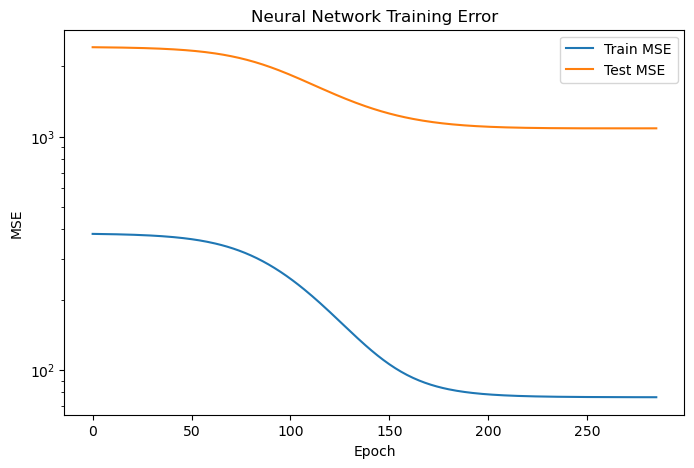

Train MAE:  5.918
Test MAE:   31.934
Train RMSE: 8.741
Test RMSE:  32.937


/var/folders/4j/3hhj_cmd3gnc44qd4552bf_40000gn/T/ipykernel_66657/2559575209.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  preds.append(float(f(x)))


In [165]:
plt.figure(figsize=(8, 5))
plt.plot(range(len(errors)), errors, label="Train MSE")
plt.plot(range(len(test_errors)), test_errors, label="Test MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Neural Network Training Error")
plt.yscale("log")
plt.legend()
plt.show()

train_preds = predict_matrix(X_train)
test_preds = predict_matrix(X_test)

train_mae = np.mean(np.abs(train_preds - y_train))
test_mae = np.mean(np.abs(test_preds - y_test))

train_rmse = np.sqrt(np.mean((train_preds - y_train) ** 2))
test_rmse = np.sqrt(np.mean((test_preds - y_test) ** 2))

print(f"Train MAE:  {train_mae:.3f}")
print(f"Test MAE:   {test_mae:.3f}")
print(f"Train RMSE: {train_rmse:.3f}")
print(f"Test RMSE:  {test_rmse:.3f}")

## Visualize predictions

/var/folders/4j/3hhj_cmd3gnc44qd4552bf_40000gn/T/ipykernel_66657/2559575209.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  preds.append(float(f(x)))


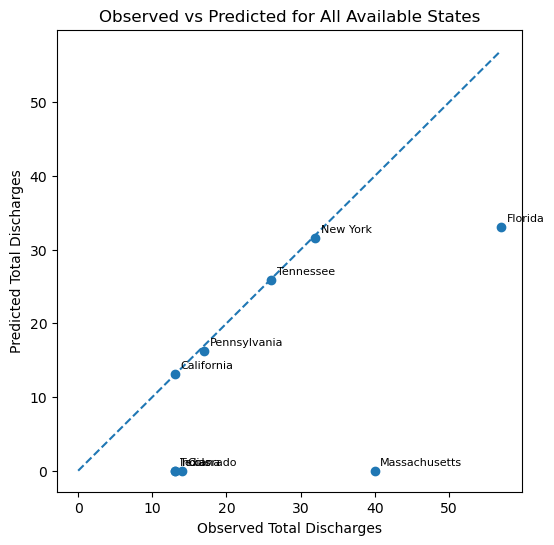

In [166]:
all_X = np.vstack([X_train, X_test])
all_actual = np.concatenate([y_train, y_test])
all_preds = predict_matrix(all_X)

plt.figure(figsize=(6, 6))
plt.scatter(all_actual, all_preds)

min_val = min(all_actual.min(), all_preds.min())
max_val = max(all_actual.max(), all_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

all_states = list(X_train_df.index) + list(X_test_df.index)
for idx, row_idx in enumerate(all_states):
    state_name = model_df.loc[row_idx, "State"]
    plt.annotate(state_name, (all_actual[idx], all_preds[idx]), fontsize=8, xytext=(4, 4), textcoords="offset points")

plt.xlabel("Observed Total Discharges")
plt.ylabel("Predicted Total Discharges")
plt.title("Observed vs Predicted for All Available States")
plt.show()